In [1]:
from copy import deepcopy
from pathlib import Path
from torch.utils.data import DataLoader
from utils import (
    OCTMendeleyDataset, 
    plotimg, 
    LitSupervised, 
    OCTRandAugment, 
    TransferLearning, 
    GLOBAL_CONFIG,
    product_dict,
    MAGNITUDE_MAX_RANGE,
    stringify_map,
    LOGDIR,
    TransferLearningModel,
)
import torch
from torch import nn
from torchvision.models import (
    resnet18,
    ResNet18_Weights,
    resnet34,
    ResNet34_Weights,
    resnet50,
    ResNet50_Weights,
    resnet101,
    ResNet101_Weights,
    resnet152,
    ResNet152_Weights,
    densenet121,
    DenseNet121_Weights,
    densenet161,
    DenseNet161_Weights,
    densenet169,
    DenseNet169_Weights,
    densenet201,
    DenseNet201_Weights,
)
from torchvision.transforms import v2
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from torchinfo import summary

In [2]:
train_dataset = OCTMendeleyDataset("train", preprocessed_suffix="mv2middle")
validation_dataset = OCTMendeleyDataset("val", preprocessed_suffix="mv2middle")
test_dataset = OCTMendeleyDataset("test", preprocessed_suffix="mv2middle")

In [3]:
OCTMendeleyDataset.classes()

['DME', 'AMD', 'DRUSEN', 'DR', 'CNV', 'NORMAL', 'CSR', 'MH']

In [4]:
_index = 6
path, _ = test_dataset.path_instance_pair(_index)
instance, label = test_dataset[_index]

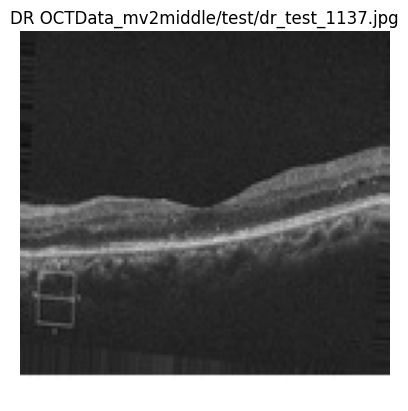

In [5]:
plotimg(instance, f"{OCTMendeleyDataset.classes()[label]} {path}")

In [6]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=GLOBAL_CONFIG["batch_size"], 
    num_workers=7,
)
validation_loader = DataLoader(
    validation_dataset, 
    batch_size=GLOBAL_CONFIG["batch_size"], 
    num_workers=7,
)

In [7]:
TransferLearning.models = {
    #"resnet18": TransferLearningModel(resnet18, ResNet18_Weights.IMAGENET1K_V1),
    "resnet34": TransferLearningModel(resnet34, ResNet34_Weights.IMAGENET1K_V1),
    "resnet50": TransferLearningModel(resnet50, ResNet50_Weights.IMAGENET1K_V1),
    #"resnet101": TransferLearningModel(resnet101, ResNet101_Weights.IMAGENET1K_V2),
    #"resnet152": TransferLearningModel(resnet152, ResNet152_Weights.IMAGENET1K_V1),
    #"densenet121": TransferLearningModel(densenet121, DenseNet121_Weights.IMAGENET1K_V1),
    #"densenet161": TransferLearningModel(densenet161, DenseNet161_Weights.IMAGENET1K_V1),
    #"densenet169": TransferLearningModel(densenet169, DenseNet169_Weights.IMAGENET1K_V1),
    #"densenet201": TransferLearningModel(densenet201, DenseNet201_Weights.IMAGENET1K_V1),
}

In [8]:
def tune_model(configs):
    LOGCONFIG = "config.txt"
    log_config_path = LOGDIR / Path(LOGCONFIG)

    last_config = None
    if log_config_path.exists():
        with open(log_config_path, "r") as fconfig:
            last_config = eval(fconfig.read())

    configarr = list(product_dict(configs))
    last_index = configarr.index(last_config) if isinstance(last_config, dict) else None
    
    current_config = None
    current_name = None
    try:
        for current_index, config in enumerate(configarr):
            if isinstance(last_index, int) and current_index < last_index:
                continue
            ckpt_path = None
            current_name = stringify_map(config, ", ")
            version_name = stringify_map(config)
            
            if current_index == last_index:
               print(f"Resuming at {current_name}")
               ckpts_path = Path(LOGDIR, version_name, "checkpoints")
               if ckpts_path.exists():
                   ckpts_arr = sorted(list(ckpts_path.iterdir()))
                   ckpt_path = None if ckpts_arr == [] else ckpts_arr[-1]
            else:
               print(current_name)

            current_config = config

            logger = TensorBoardLogger(
               save_dir=".",
               name=LOGDIR,
               version=version_name,
            )
            trainer = L.Trainer(
               logger=logger,
               accelerator="gpu",
               callbacks=EarlyStopping(
                  monitor=LitSupervised.VALIDATION_LOSS, 
                  mode="min",
                  min_delta=1e-3, 
                  patience=8,
               ),
            )
            litmodel = LitSupervised(config)
            
            trainer.fit(
               model=litmodel, 
               train_dataloaders=train_loader, val_dataloaders=validation_loader,
               ckpt_path=ckpt_path,
            )

    except KeyboardInterrupt:
        if isinstance(current_config, dict):
            print(f"Saving {current_name}...")
            with open(log_config_path, "w") as fconfig:
                fconfig.write(str(current_config))

In [9]:
def train_model(config, ckpt_config = None):
   current_name = stringify_map(config, ", ")
   version_name = stringify_map(config)
   logdir = config["logdir"]
   print(current_name)
   logger = TensorBoardLogger(
      save_dir=".",
      name=logdir,
      version=version_name,
   )
   trainer = L.Trainer(
      logger=logger,
      accelerator="gpu",
      callbacks=EarlyStopping(
         monitor=LitSupervised.VALIDATION_LOSS, 
         mode="min",
         min_delta=1e-3, 
         patience=8,
      ),
   )
   litmodel = LitSupervised(config)
   ckpt_path = None
   if isinstance(ckpt_config, dict):
      ckpt_version_name = stringify_map(ckpt_config)
      ckpts_path = Path(logdir, ckpt_version_name, "checkpoints")
      ckpt_path = sorted(list(ckpts_path.iterdir()))[-1]
   trainer.fit(
      model=litmodel, 
      train_dataloaders=train_loader, val_dataloaders=validation_loader,
      ckpt_path=ckpt_path,
   )

In [10]:
#summary(TransferLearning.models["densenet161"].model, input_size=(80,3,128,128), depth=2)

In [11]:
for model_name in TransferLearning.models:
    print(f"Running {model_name}:")
    train_model(
        {
            "run": "step1", 
            "logdir": "logs_mvmiddle",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-3
        },
    )
    train_model(
        {
            "run": "step2", 
            "logdir": "logs_mvmiddle",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-4
        },
        {
            "run": "step1", 
            "logdir": "logs_mvmiddle",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-3
        }
    )

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Running resnet34:
run:step1, logdir:logs_mvmiddle, model:resnet34, magnitude:0, lr:0.001


/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 5080 Laptop GPU') that has Tensor

Freezing weights
Epoch 25: 100%|██████████| 230/230 [00:15<00:00, 15.30it/s, v_num=.001, Validation Loss=0.668, Validation Accuracy=0.743, Train Loss=0.563, Train Accuracy=0.784]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory ./logs_mvmiddle/run:step2_logdir:logs_mvmiddle_model:resnet34_magnitude:0_lr:0.0001/checkpoints exists and is not empty.
Restoring states from the checkpoint path at logs_mvmiddle/run:step1_logdir:logs_mvmiddle_model:resnet34_magnitude:0_lr:0.001/checkpoints/epoch=26-step=6210.ckpt


...

Freezing weights
Epoch 29: 100%|██████████| 230/230 [00:18<00:00, 12.68it/s, v_num=.001, Validation Loss=0.545, Validation Accuracy=0.800, Train Loss=0.380, Train Accuracy=0.861]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Restoring states from the checkpoint path at logs_mvmiddle/run:step1_logdir:logs_mvmiddle_model:resnet50_magnitude:0_lr:0.001/checkpoints/epoch=29-step=6900.ckpt


run:step2, logdir:logs_mvmiddle, model:resnet50, magnitude:0, lr:0.0001
Unfreezing weights


/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:445: The dirpath has changed from './logs_mvmiddle/run:step1_logdir:logs_mvmiddle_model:resnet50_magnitude:0_lr:0.001/checkpoints' to './logs_mvmiddle/run:step2_logdir:logs_mvmiddle_model:resnet50_magnitude:0_lr:0.0001/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | model | ResNet | 23.5 M | train
-----------------------------------------
23.5 M    Trainable params
0         Non-trainable params
23.5 M    Total params
94.098    Total estimated model params size (MB)
151       Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at logs_mvmiddle/run:step1_logdir:logs_m

Epoch 41: 100%|██████████| 230/230 [00:45<00:00,  5.08it/s, v_num=0001, Validation Loss=0.192, Validation Accuracy=0.947, Train Loss=0.0424, Train Accuracy=0.985]
